In [1]:
import kagglehub
import os

# Download latest version
kagglehub.dataset_download("kadirduran/hr-dataset",output_dir=os.path.join(os.getcwd(),'datasetV2'))

d:\Projects\HR_Project\hr_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'd:\\Projects\\HR_Project\\notebook\\datasetV2'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('datasetV2/HR_Dataset.csv')

In [4]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Departments,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [5]:
df['left'].unique()

array([1, 0])

In [6]:
left = df['left'].value_counts()
print(left)

left
0    11428
1     3571
Name: count, dtype: int64


In [7]:
left_percent = left[1]/(left[0]+left[1])
print(f'{left_percent:.4f}')

0.2381


Insights: Left Percentage --> 23.81 percentage

In [8]:
cat = [item for item in df.columns if df[item].dtype == 'str']
num = [item for item in df.columns if df[item].dtype != 'str' and item!='left']
print(f'Categories:{len(cat)}:{cat},\nNumerical:{len(num)}:{num}')

Categories:2:['Departments ', 'salary'],
Numerical:7:['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years']


Observation: The column Department have an extra space in it will cause problems in the future so we remove the extra space in it... 

In [9]:
a_l = []
for i in range(len(df.columns)):
    a = df.columns[i].split()
    a_l.append(a[0])
print(a_l)

['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'Departments', 'salary']


In [10]:
df.columns = a_l
cat = [item for item in df.columns if df[item].dtype == 'str']
num = [item for item in df.columns if df[item].dtype != 'str' and item!='left']
print(f'Categories:{len(cat)}:{cat},\nNumerical:{len(num)}:{num}')

Categories:2:['Departments', 'salary'],
Numerical:7:['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years']


<Axes: >

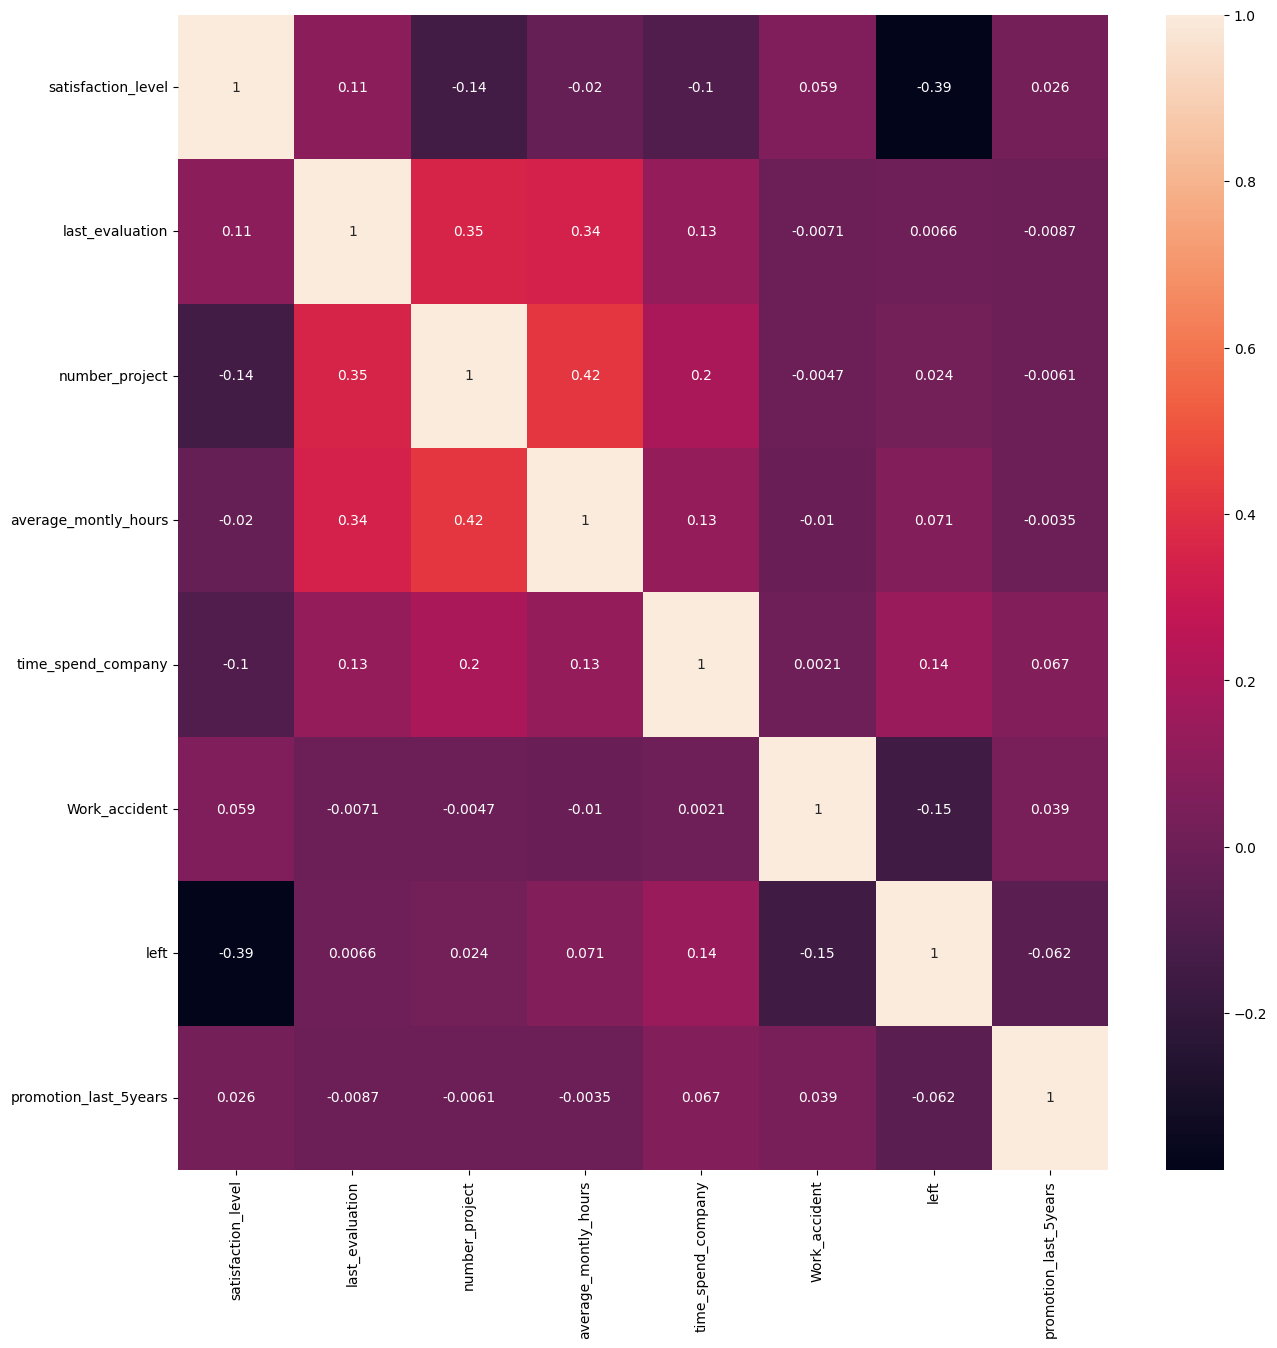

In [11]:
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(numeric_only=True),annot=True)

Insights : Saw a little notable negative correlation between satisfaction level and leaving company

In [12]:
X = df.drop('left',axis=1)
y =df['left']

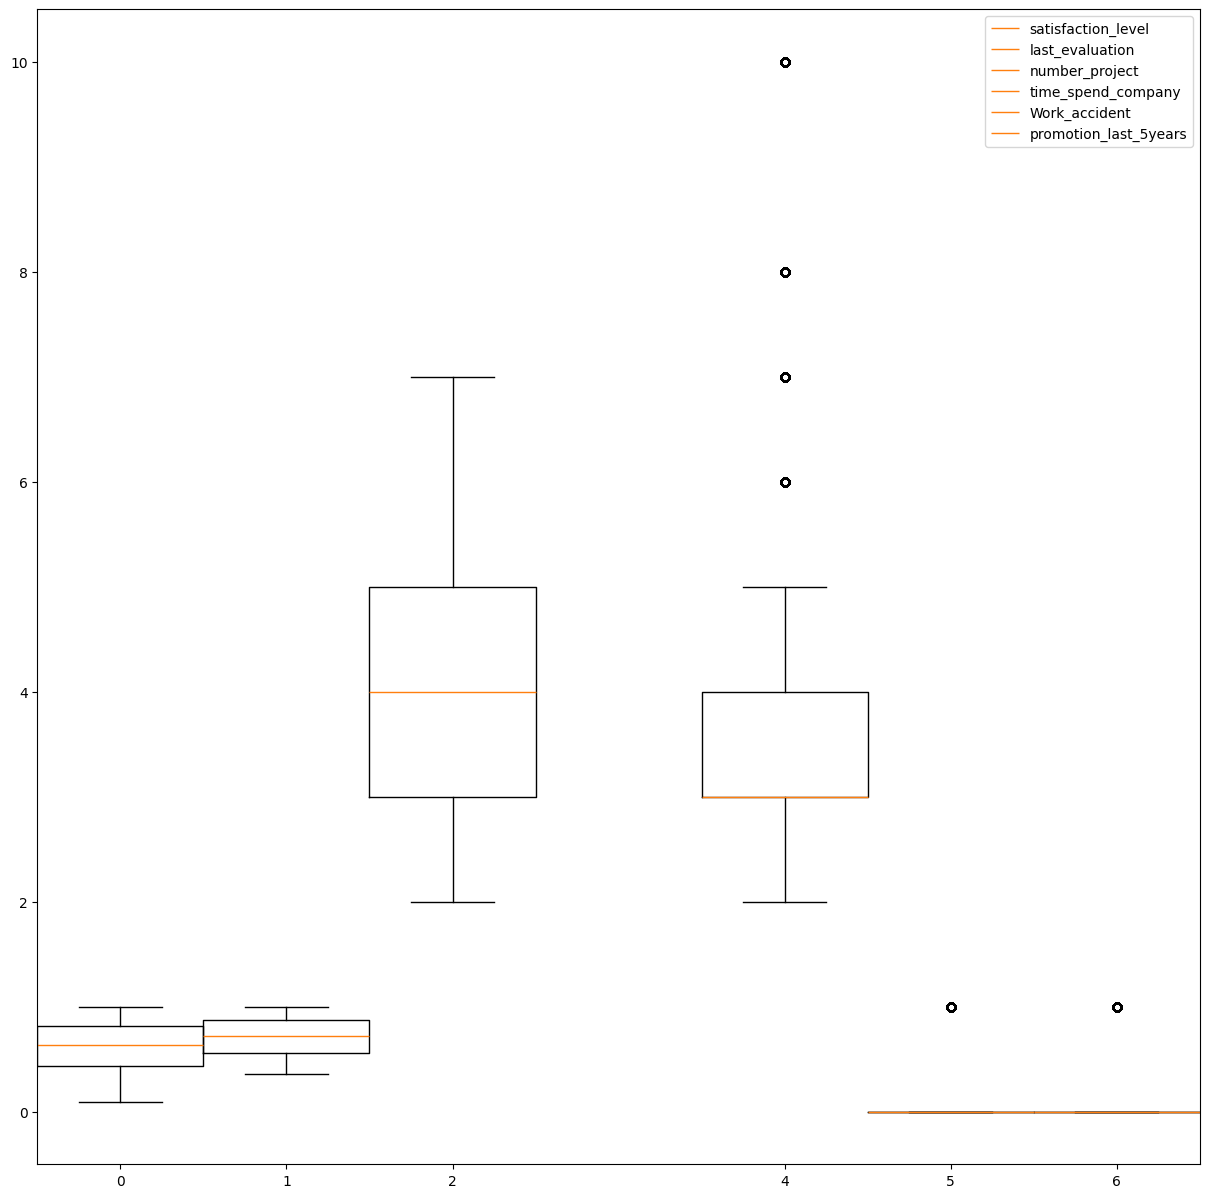

In [13]:
plt.figure(figsize=(15,15))
for _,i in enumerate(num):
  if _!=3:
   plt.boxplot(df[i],positions=[_],widths=1,label=i)
   plt.legend()
  else:
    pass

In [14]:
cat

['Departments', 'salary']

In [15]:
df.groupby('Departments')['left'].mean()

Departments
IT             0.222494
RandD          0.153748
accounting     0.265971
hr             0.290934
management     0.144444
marketing      0.236597
product_mng    0.219512
sales          0.244928
support        0.248991
technical      0.256250
Name: left, dtype: float64

Insights: RandD and Management is mostly less likely to leave the company

In [16]:
df.salary.value_counts()

salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64

In [17]:
df.groupby('salary')['left'].mean().sort_values()

salary
high      0.066289
medium    0.204313
low       0.296884
Name: left, dtype: float64

Insights: --> High Salary is less likely to leave the company

In [18]:
df.groupby(['salary','Departments'])['left'].mean()

salary  Departments
high    IT             0.048193
        RandD          0.078431
        accounting     0.067568
        hr             0.133333
        management     0.004444
        marketing      0.112500
        product_mng    0.088235
        sales          0.052045
        support        0.056738
        technical      0.124378
low     IT             0.282430
        RandD          0.151099
        accounting     0.276536
        hr             0.274627
        management     0.327778
        marketing      0.313433
        product_mng    0.232816
        sales          0.332063
        support        0.339442
        technical      0.275510
medium  IT             0.181308
        RandD          0.166667
        accounting     0.298507
        hr             0.325905
        management     0.137778
        marketing      0.180851
        product_mng    0.227154
        sales          0.170993
        support        0.167728
        technical      0.256321
Name: left, dtype: f

In [19]:
df.groupby(['salary','Departments'])['left'].mean().sort_values()

salary  Departments
high    management     0.004444
        IT             0.048193
        sales          0.052045
        support        0.056738
        accounting     0.067568
        RandD          0.078431
        product_mng    0.088235
        marketing      0.112500
        technical      0.124378
        hr             0.133333
medium  management     0.137778
low     RandD          0.151099
medium  RandD          0.166667
        support        0.167728
        sales          0.170993
        marketing      0.180851
        IT             0.181308
        product_mng    0.227154
low     product_mng    0.232816
medium  technical      0.256321
low     hr             0.274627
        technical      0.275510
        accounting     0.276536
        IT             0.282430
medium  accounting     0.298507
low     marketing      0.313433
medium  hr             0.325905
low     management     0.327778
        sales          0.332063
        support        0.339442
Name: left, dtype: f

Insight: Low Salaried support left the comapny most , whereas Low salaried R&D is lot less likely to leave the company ,leaving rate of high salaried Management is negligable.

In [20]:
## Satisfaction Rate of persons acc to department
df.groupby(['salary','Departments'])['satisfaction_level'].mean().sort_values()

# df.groupby('salary')['satisfaction_level'].mean().sort_values()

salary  Departments
low     accounting     0.574162
medium  hr             0.580306
        accounting     0.583642
high    RandD          0.586667
low     support        0.591710
        technical      0.594322
medium  management     0.597867
low     sales          0.600838
        marketing      0.602910
high    marketing      0.605250
low     hr             0.608657
        IT             0.610099
        management     0.610722
high    accounting     0.614054
        product_mng    0.614118
medium  product_mng    0.619112
        RandD          0.620349
low     product_mng    0.620909
medium  technical      0.620968
low     RandD          0.623929
medium  IT             0.624187
        sales          0.625327
high    technical      0.625970
        IT             0.638193
medium  marketing      0.638218
        support        0.645149
high    sales          0.648959
        management     0.653333
        support        0.655035
        hr             0.673111
Name: satisfaction_l

Insights: High salaried Hr are the happiest

In [21]:
df.groupby(['Work_accident','salary'])['left'].mean().sort_values()

Work_accident  salary
1              high      0.000000
0              high      0.078469
1              medium    0.078975
               low       0.091346
0              medium    0.225631
               low       0.330943
Name: left, dtype: float64

##### Workaccident is not related to left person who left , people who have done Work_accident is less likely to leave.

In [22]:
df.groupby(['promotion_last_5years'])['left'].mean().sort_values()

promotion_last_5years
1    0.059561
0    0.241962
Name: left, dtype: float64

Insights: person who dont get promotion is more likely to leave company....

In [23]:
num

['satisfaction_level',
 'last_evaluation',
 'number_project',
 'average_montly_hours',
 'time_spend_company',
 'Work_accident',
 'promotion_last_5years']

In [24]:
df.groupby(['number_project'])['left'].mean().sort_values()

number_project
3    0.017756
4    0.093700
5    0.221659
6    0.557922
2    0.656198
7    1.000000
Name: left, dtype: float64

In [25]:
df.groupby(['Departments','number_project'])['left'].mean().sort_values()

Departments  number_project
product_mng  3                 0.000000
IT           3                 0.005764
accounting   3                 0.010050
management   3                 0.011696
marketing    3                 0.012146
RandD        3                 0.012146
sales        3                 0.014679
support      3                 0.026846
technical    3                 0.029703
hr           3                 0.032407
RandD        4                 0.062222
management   4                 0.062802
IT           4                 0.066282
product_mng  4                 0.072519
support      4                 0.080000
management   5                 0.084746
marketing    4                 0.095618
sales        4                 0.097479
technical    4                 0.111392
accounting   4                 0.126697
hr           4                 0.144144
accounting   5                 0.164286
RandD        5                 0.190184
marketing    5                 0.207143
IT          

In [26]:
df.groupby(['salary','number_project'])['left'].mean().sort_values()

salary  number_project
high    4                 0.005435
        3                 0.007353
medium  3                 0.017241
low     3                 0.020659
high    5                 0.061224
medium  4                 0.082723
low     4                 0.119310
high    6                 0.178082
medium  5                 0.188490
low     5                 0.281701
high    2                 0.328571
medium  6                 0.506410
        2                 0.613938
low     6                 0.639810
        2                 0.718750
high    7                 1.000000
low     7                 1.000000
medium  7                 1.000000
Name: left, dtype: float64

In [27]:
df[df['number_project']==7].left.value_counts()

left
1    256
Name: count, dtype: int64

Insight: 
1) Person who works on 7 project will definetely leave the company...
2) 3-4 project is the sweet spot if person working on 3 projects he is very unlikely to leave the company...

In [28]:
df.groupby(['Departments'])['average_montly_hours'].mean().sort_values()

Departments
hr             198.684709
marketing      199.385781
product_mng    199.965632
support        200.758188
RandD          200.800508
sales          200.911353
accounting     201.162973
management     201.249206
IT             202.215974
technical      202.497426
Name: average_montly_hours, dtype: float64

Insights: On average Technician & It department works more...


In [29]:
df.groupby(['salary','Departments'])['average_montly_hours'].mean().sort_values()

salary  Departments
high    marketing      185.575000
medium  hr             193.863510
high    product_mng    194.632353
        IT             194.927711
medium  marketing      196.869681
low     RandD          198.747253
        support        198.900524
medium  product_mng    199.637076
high    RandD          199.745098
low     accounting     199.899441
high    technical      200.044776
        management     200.248889
low     sales          200.363030
        management     200.744444
        product_mng    201.048780
high    sales          201.178439
low     IT             201.382594
medium  accounting     201.465672
        sales          201.520316
        technical      202.248474
low     hr             202.456716
medium  support        202.535032
        management     202.653333
        RandD          202.954301
low     technical      203.064869
high    support        203.985816
medium  IT             204.295327
low     marketing      204.487562
high    accounting     205.9

Note: 
- High salaried Hr works most in an company

In [30]:
df.groupby(['salary','left','Departments'])['average_montly_hours'].mean().sort_values()

salary  left  Departments
high    1     marketing      142.000000
              accounting     170.000000
              RandD          171.000000
              support        176.500000
              technical      185.120000
              product_mng    190.000000
medium  1     hr             190.623932
high    0     marketing      191.098592
              IT             194.329114
              product_mng    195.080645
medium  0     hr             195.429752
              accounting     196.455319
low     0     support        196.515192
medium  0     marketing      196.590909
low     0     RandD          197.472492
medium  0     technical      197.474795
low     0     product_mng    197.606936
        1     management     197.779661
        0     IT             197.903890
medium  1     marketing      198.132353
        0     product_mng    198.513514
low     0     sales          198.582026
              technical      198.672032
high    0     sales          198.792157
low     0     

In [31]:
num

['satisfaction_level',
 'last_evaluation',
 'number_project',
 'average_montly_hours',
 'time_spend_company',
 'Work_accident',
 'promotion_last_5years']

In [32]:
df.groupby(['salary','number_project','Departments'])['average_montly_hours'].mean().sort_values()

salary  number_project  Departments
high    2               RandD          133.200000
                        marketing      138.285714
medium  2               hr             147.810127
low     2               IT             149.300000
medium  2               RandD          151.594595
                                          ...    
        7               IT             290.272727
                        hr             290.285714
                        product_mng    293.250000
low     7               IT             293.666667
                        hr             296.500000
Name: average_montly_hours, Length: 171, dtype: float64

In [33]:
df.groupby(['salary','left','number_project','Departments'])['average_montly_hours'].mean().sort_values()

salary  left  number_project  Departments
high    1     2               support        130.000000
        0     2               marketing      131.600000
        1     2               RandD          132.666667
        0     2               RandD          134.000000
medium  1     2               RandD          138.750000
                                                ...    
              7               hr             290.285714
                              product_mng    293.250000
low     1     7               IT             293.666667
                              hr             296.500000
high    1     6               sales          301.500000
Name: average_montly_hours, Length: 288, dtype: float64

Insight: 
1) Marketing & RandD person despite having high salary and low work hours will leave the company

In [34]:
df.groupby(['time_spend_company','salary'])['left'].mean()

time_spend_company  salary
2                   high      0.000000
                    low       0.014407
                    medium    0.021924
3                   high      0.088462
                    low       0.307644
                    medium    0.203826
4                   high      0.092486
                    low       0.416154
                    medium    0.307196
5                   high      0.303030
                    low       0.610763
                    medium    0.534539
6                   high      0.000000
                    low       0.405405
                    medium    0.224242
7                   high      0.000000
                    low       0.000000
                    medium    0.000000
8                   high      0.000000
                    low       0.000000
                    medium    0.000000
10                  high      0.000000
                    low       0.000000
                    medium    0.000000
Name: left, dtype: float64

In [35]:
df__ = df.drop(columns=['average_montly_hours','time_spend_company','number_project'])

<Axes: ylabel='salary'>

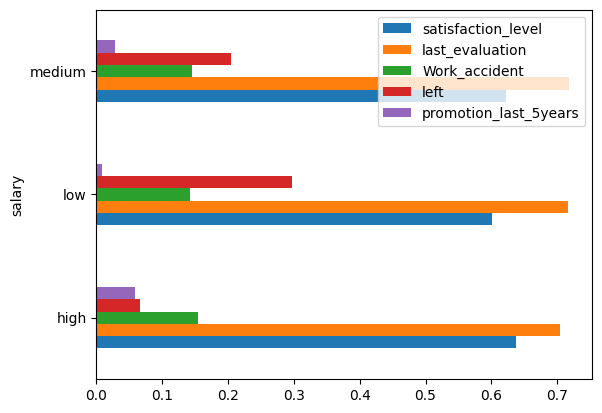

In [36]:
df__.groupby('salary').mean(numeric_only=True,).plot(kind='barh')

## Scenerio_1 : Using column Last Evaluation

Insights:
- Persons who works more than 7 years will not leave company despite having low salary
- most number of people leave the company in 5th year

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import classification_report,accuracy_score

cat = [item for item in df.columns if df[item].dtype == 'str']
num = [item for item in df.columns if df[item].dtype != 'str' and item!='left']
print(f'Categories:{len(cat)}:{cat},\nNumerical:{len(num)}:{num}')

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)
X_train,X_val,y_train,y_val = train_test_split(X_train,y_train,test_size=0.1,random_state=42)

Categories:2:['Departments', 'salary'],
Numerical:7:['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years']


In [38]:
X_train.shape

(10124, 9)

In [39]:
size_order = ['low','medium','high']
ord_enc= OrdinalEncoder(categories=[size_order],handle_unknown='use_encoded_value',unknown_value=-1)
ohe = OneHotEncoder(categories='auto',drop='first',sparse_output=False)
transformer_salary = Pipeline(steps=[('Ordinal',ord_enc),('scaler',MinMaxScaler())])
transformer_ohe = Pipeline(steps=[('Ohe',OneHotEncoder(drop='first'))])
transformer_num = Pipeline(steps=[('minMax_scaler',MinMaxScaler())])
pre_pipeline = ColumnTransformer(transformers=[('ord_encoder_for_salary',transformer_salary,['salary']),
                                               ('oheEncoder_for_departments',transformer_ohe,['Departments']),
                                               ('MinMaxEncoder_for_remaining',transformer_num,num)],
                                               remainder='passthrough')

In [40]:
pre_pipeline

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ord_encoder_for_salary', ...), ('oheEncoder_for_departments', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field na

In [41]:
def scaled_data(transformer,data,fit= 0):
    if fit ==0:
        X_try = transformer.fit_transform(data)
        list_col = transformer.get_feature_names_out()
        names_list = [names.split('__')[1] for names in list_col]
        X_try= pd.DataFrame(X_try,columns=names_list)
        return X_try
    else:
        X_try = transformer.transform(data)
        list_col = transformer.get_feature_names_out()
        names_list = [names.split('__')[1] for names in list_col]
        X_try= pd.DataFrame(X_try,columns=names_list)
        return X_try

In [42]:
X_train = scaled_data(pre_pipeline,X_train)
X_val = scaled_data(pre_pipeline,X_val,fit=1)
X_test = scaled_data(pre_pipeline,X_test,fit=1)

In [43]:
X_train

,salary,Departments_RandD,Departments_accounting,Departments_hr,Departments_management,Departments_marketing,Departments_product_mng,Departments_sales,Departments_support,Departments_technical,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.010989,0.953125,1.0,0.738318,0.250,0.0,0.0
1,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.054945,0.500000,0.4,0.827103,0.375,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.505495,0.843750,0.4,0.481308,0.125,0.0,0.0
3,0.5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.846154,0.953125,0.6,0.808411,0.375,0.0,0.0
4,0.5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.868132,0.500000,0.6,0.285047,0.250,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10119,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.428571,0.093750,0.0,0.836449,0.500,1.0,1.0
10120,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.373626,0.312500,0.0,0.186916,0.125,0.0,0.0
10121,0.5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.021978,0.906250,1.0,0.962617,0.250,0.0,0.0
10122,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.747253,0.828125,0.6,0.686916,0.375,0.0,0.0


In [44]:
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_train_pred = rf.predict(X_train)
print(pd.DataFrame(zip(y_train_pred,y_train)))
print(classification_report(y_train_pred,y_train))
y_pred = rf.predict(X_test)
accuracy_score(y_pred,y_test)

       0  1
0      1  1
1      0  0
2      0  0
3      1  1
4      0  0
...   .. ..
10119  0  0
10120  1  1
10121  1  1
10122  1  1
10123  0  0

[10124 rows x 2 columns]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7719
           1       1.00      1.00      1.00      2405

    accuracy                           1.00     10124
   macro avg       1.00      1.00      1.00     10124
weighted avg       1.00      1.00      1.00     10124



0.9874666666666667

## Scenerio_2 : Drop last evaluation_col

In [45]:
df_without_val = df.drop('last_evaluation',axis=1)
cat = [item for item in df_without_val.columns if df_without_val[item].dtype == 'str']
num = [item for item in df_without_val.columns if df_without_val[item].dtype != 'str' and item!='left']
print(f'Categories:{len(cat)}:{cat},\nNumerical:{len(num)}:{num}')
X = df_without_val.drop('left',axis=1)
y = df_without_val['left']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)
X_train,X_val,y_train,y_val = train_test_split(X_train,y_train,test_size=0.1,random_state=42)

Categories:2:['Departments', 'salary'],
Numerical:6:['satisfaction_level', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years']


In [46]:
size_order = ['low','medium','high']
ord_enc= OrdinalEncoder(categories=[size_order],handle_unknown='use_encoded_value',unknown_value=-1)
ohe = OneHotEncoder(categories='auto',drop='first',sparse_output=False)
transformer_salary = Pipeline(steps=[('Ordinal',ord_enc),('scaler',MinMaxScaler())])
transformer_ohe = Pipeline(steps=[('Ohe',OneHotEncoder(drop='first'))])
transformer_num = Pipeline(steps=[('minMax_scaler',MinMaxScaler())])
pre_pipeline_without_eval = ColumnTransformer(transformers=[('ord_encoder_for_salary',transformer_salary,['salary']),
                                               ('oheEncoder_for_departments',transformer_ohe,['Departments']),
                                               ('MinMaxEncoder_for_remaining',transformer_num,num)],
                                               remainder='passthrough')

In [47]:
X_train = scaled_data(pre_pipeline_without_eval,X_train)
X_val = scaled_data(pre_pipeline_without_eval,X_val,fit=1)
X_test = scaled_data(pre_pipeline_without_eval,X_test,fit=1)

In [48]:
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_train_pred = rf.predict(X_train)
print(pd.DataFrame(zip(y_train_pred,y_train)))
print(classification_report(y_train_pred,y_train))
y_pred = rf.predict(X_test)
accuracy_score(y_pred,y_test)

       0  1
0      1  1
1      0  0
2      0  0
3      1  1
4      0  0
...   .. ..
10119  0  0
10120  1  1
10121  1  1
10122  1  1
10123  0  0

[10124 rows x 2 columns]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7718
           1       1.00      1.00      1.00      2406

    accuracy                           1.00     10124
   macro avg       1.00      1.00      1.00     10124
weighted avg       1.00      1.00      1.00     10124



0.9866666666666667

In [49]:
xg = XGBClassifier()
xg.fit(X_train,y_train)
y_train_pred = xg.predict(X_train)
print(pd.DataFrame(zip(y_train_pred,y_train)))
print(classification_report(y_train_pred,y_train))
y_pred = xg.predict(X_test)
accuracy_score(y_pred,y_test)

       0  1
0      1  1
1      0  0
2      0  0
3      1  1
4      0  0
...   .. ..
10119  0  0
10120  1  1
10121  1  1
10122  1  1
10123  0  0

[10124 rows x 2 columns]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7734
           1       0.99      0.99      0.99      2390

    accuracy                           0.99     10124
   macro avg       0.99      0.99      0.99     10124
weighted avg       0.99      0.99      0.99     10124



0.9826666666666667

## HyperTuining

In [50]:
y_train.isnull().sum()

np.int64(0)

In [51]:
y_test.isnull().sum()

np.int64(0)

In [52]:
y_val.isnull().sum()

np.int64(0)

In [53]:
Ord_cat = ['low','medium','high']
pipeline_ohe = Pipeline(steps=[
                ('Ordinal_Encoder',OrdinalEncoder(categories=[Ord_cat],handle_unknown='use_encoded_value',unknown_value=-1)),
                ('MixMaxScaler',MinMaxScaler())
                ])
pipeline_cat = ColumnTransformer(transformers=[
                ('Salary',pipeline_ohe,['salary']),
                ('Department_cols',OneHotEncoder(drop='first',sparse_output=False),['Departments'])
            ],remainder='passthrough')
preprocesser = ColumnTransformer(transformers=[
                        ('Category',pipeline_cat,cat),('Numeric',MinMaxScaler(),num)],
                        remainder='passthrough') 
preprocesser

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Category', ...), ('Numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featur

In [54]:
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Departments,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [55]:
dfff = preprocesser.fit_transform(df)
dfff = pd.DataFrame(dfff,columns=preprocesser.get_feature_names_out())

In [56]:
dfff['remainder__left'].unique()

array([1., 0.])

In [58]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Departments', 'salary'],
      dtype='str')

In [72]:
df['Departments'].unique().tolist()

['sales',
 'accounting',
 'hr',
 'technical',
 'support',
 'management',
 'IT',
 'product_mng',
 'marketing',
 'RandD']